In [1]:
!pip install spectralexplain

In [1]:
import spectralexplain as spex
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import r2_score
import pickle   
import os

# Publication-ish defaults scaled up so each two-panel strip stays legible after
# placing two exported figures side-by-side at ~half page width each (~3.35–3.5 in).
NEURIPS_RC = {
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.05,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "grid.linewidth": 0.55,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
}

mpl.rcParams.update(NEURIPS_RC)

/u/sdickman/micromamba/envs/mf2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def display_time(name, time, rmax=True, save_path=None):
    rmax_str = "" if rmax else "_max=False"
    dir = "/projects/beir/lbutler3/protein/data/spex/"
    cand_a = os.path.join(dir, f"fourier_dict_{time}.pkl")
    cand_b = os.path.join(dir, f"fourier_dict__{name}_{time}.pkl")
    pkl_path = cand_a if os.path.isfile(cand_a) else cand_b
    fourier_dict = pickle.load(open(pkl_path, "rb"))
    heldout_masks = np.loadtxt(dir + f"heldout_masks_{time}{rmax_str}.txt", dtype=int).astype(bool)
    y_true = np.loadtxt(dir + f"y_true_{time}{rmax_str}.txt")
    print("Held out masks shape:", heldout_masks.shape)
    print(f"Successfully loaded experiment: {time}")

    np.random.seed(42)

    def reconstruct_predictions(masks, fdict):
        masks = np.asarray(masks, dtype=bool)
        preds = np.zeros(len(masks), dtype=float)

        for freq, coef in fdict.items():
            active = np.asarray(freq, dtype=bool)
            if not active.any():
                preds += float(coef)
            else:
                parity = masks[:, active].sum(axis=1) % 2
                preds += float(coef) * ((-1) ** parity)

        return preds

    y_pred = reconstruct_predictions(heldout_masks, fourier_dict)
    full_r2 = r2_score(y_true, y_pred)
    print(f"R2 Score on held-out masks: {full_r2:.4f}")

    # Sparsity curve data
    sorted_items = sorted(fourier_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    steps = np.unique(np.geomspace(1, len(sorted_items), num=20, dtype=int))

    k_values = []
    r2_values = []
    for k in steps:
        sparse_dict = dict(sorted_items[:k])
        y_pred_sparse = reconstruct_predictions(heldout_masks, sparse_dict)
        k_values.append(k)
        r2_values.append(r2_score(y_true, y_pred_sparse))

    # Variance decomposition from Fourier coefficients (orders > 4 lumped into order 4)
    MAX_ORDER = 4
    energy_by_order = {}
    mean_coef = 0.0

    for key_tuple, coef in fourier_dict.items():
        order = min(int(sum(key_tuple)), MAX_ORDER)
        energy = float(coef) ** 2

        if order == 0:
            mean_coef = float(coef)
        else:
            energy_by_order[order] = energy_by_order.get(order, 0.0) + energy

    total_variance = sum(energy_by_order.values())

    print(f"Mean term c_empty: {mean_coef:.6f}")
    print(f"Mean contribution c_empty^2: {mean_coef**2:.6f}")
    print(f"Total variance from spectrum: {total_variance:.6f}\n")

    print("--- Variance by interaction order ---")
    for order in sorted(energy_by_order):
        perc = 100 * energy_by_order[order] / total_variance if total_variance > 0 else 0.0
        print(f"Order {order}: {energy_by_order[order]:.6f} ({perc:.2f}%)")

    orders = sorted(energy_by_order)
    variances = np.array([energy_by_order[o] for o in orders], dtype=float)
    percentages = 100 * variances / variances.sum() if variances.sum() > 0 else np.zeros_like(variances)

    LINE_W = 3.2
    SPINE_LW = 2.35
    MARKER_S = 8.2

    with plt.rc_context(NEURIPS_RC):
        fig_w, fig_h = 8.45, 3.95
        fig, (ax_sp, ax_var) = plt.subplots(
            1, 2, figsize=(fig_w, fig_h), constrained_layout=True
        )

        # Left panel: R² vs truncated spectrum
        ax_sp.plot(
            k_values,
            r2_values,
            linestyle="-",
            linewidth=LINE_W,
            color="#1f77b4",
            marker=None,
            zorder=2,
        )
        ax_sp.axhline(
            full_r2,
            color="#d62728",
            linestyle="--",
            linewidth=2.4,
            zorder=3,
        )
        ax_sp.scatter(
            k_values,
            r2_values,
            s=MARKER_S ** 2,
            facecolors="#1f77b4",
            edgecolors="white",
            linewidths=1.0,
            zorder=5,
            clip_on=False,
        )
        ax_sp.set_xscale("log")
        ax_sp.set_ylim(0, 1.02)
        ax_sp.set_xlabel("Sparsity")
        ax_sp.set_ylabel(r"$R^2$")
        ax_sp.grid(True, which="major")
        ax_sp.grid(False, which="minor")
        ax_sp.set_axisbelow(True)

        for x_dec in (1, 10, 100, 1000):
            ax_sp.axvline(x_dec, color="#C2C2C2", linewidth=0.9, linestyle="-", alpha=0.55, zorder=1)

        for _sp in ax_sp.spines.values():
            _sp.set_visible(True)
            _sp.set_linewidth(SPINE_LW)

        # Right panel: variance contribution as % of total (by interaction order)
        bars = ax_var.bar(
            orders,
            percentages,
            color="#9ecae1",
            edgecolor="#4a5568",
            linewidth=1.4,
            alpha=0.72,
        )
        ax_var.set_xlabel("Interaction Order")
        ax_var.set_ylabel("Prop. of Spectral Variance")
        ax_var.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_var.set_xticks(orders)
        ax_var.set_xticklabels([str(o) if o < MAX_ORDER else f"{MAX_ORDER}+" for o in orders])
        ax_var.grid(True, axis="y")
        ax_var.grid(False, axis="x")
        ax_var.set_axisbelow(True)

        top_pct = float(percentages.max()) if len(percentages) else 0.0
        headroom = max(4.0, 0.14 * top_pct)
        ax_var.set_ylim(0.0, top_pct + headroom)
        dy = max(0.6, 0.025 * (top_pct + headroom))
        for bar, pct in zip(bars, percentages):
            if pct >= 1.0:
                pct_s = f"{pct:.0f}%" if pct >= 10 else f"{pct:.1f}%"
                ax_var.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + dy,
                    pct_s,
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    color="#334155",
                )

        for _sp in ax_var.spines.values():
            _sp.set_visible(True)
            _sp.set_linewidth(SPINE_LW)

        fig.set_constrained_layout_pads(w_pad=0.12, h_pad=0.12, rect=(0.01, 0, 0.99, 0.92))
        fig.suptitle(name, y=1.028, fontsize=21, fontweight="normal")
        if save_path is not None:
            fig.savefig(save_path, format="pdf")
            plt.show()
            plt.close(fig)
        else:
            plt.show()


In [3]:
path = "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/spex_logs/r2_data"

fourier_prefix = "fourier_dict__"
fourier_suffix = ".pkl"
fourier_pre_len = len(fourier_prefix)
fourier_su_len = len(fourier_suffix)

PROTEINS = []
TIME_STAMP_RMAX_MAP = {}
for root, dirs, files in os.walk(path):
    for filename in files:
        if "fourier_dict" in filename:
            file_name = filename[fourier_pre_len:-fourier_su_len]
            last_idx = len(file_name) - file_name[::-1].index("_")-1
            protein, time_stamp = file_name[:last_idx], file_name[last_idx+1:]
            PROTEINS.append((protein, time_stamp))
        elif "heldout_masks" in filename:
            max_idx = filename.index("max=")
            rmax = filename[max_idx+4:max_idx+8] == "True"
            time_stamp = filename[max_idx+5+len(str(rmax)):-4]
            TIME_STAMP_RMAX_MAP[time_stamp] = rmax

Average last data point (max): 0.7569
Average last data point (avg): 0.8304
Average % variance, order 1: 60.88%
Average % variance, order 2: 28.41%
Total % variance, orders 1-2: 89.28%


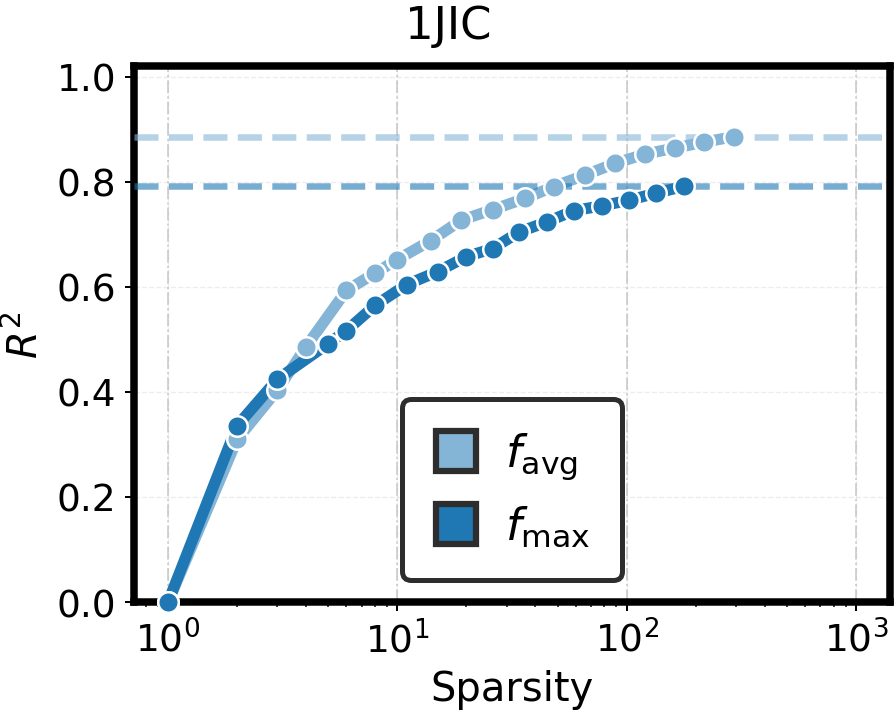

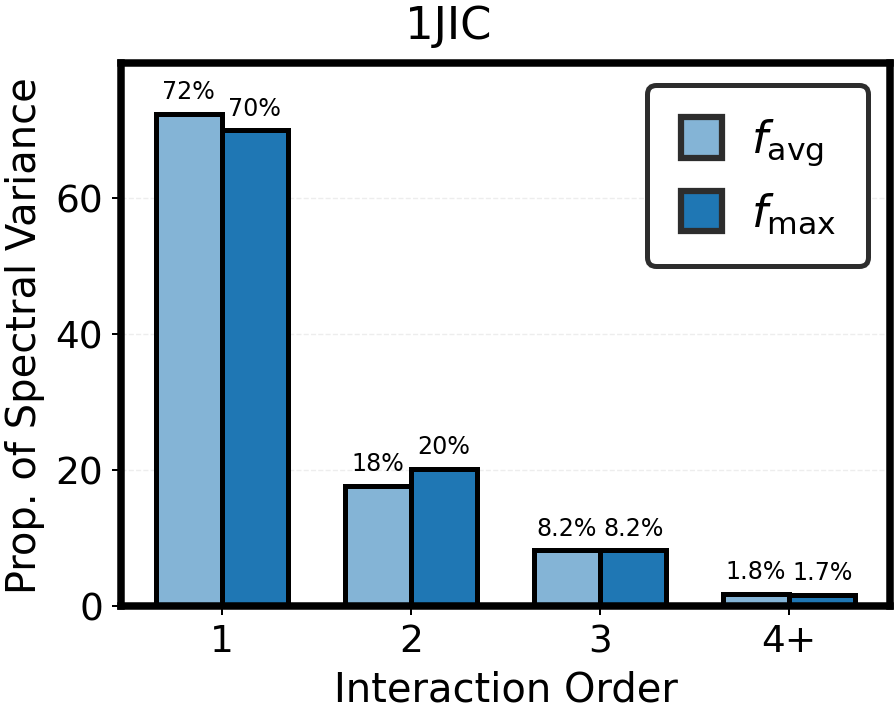

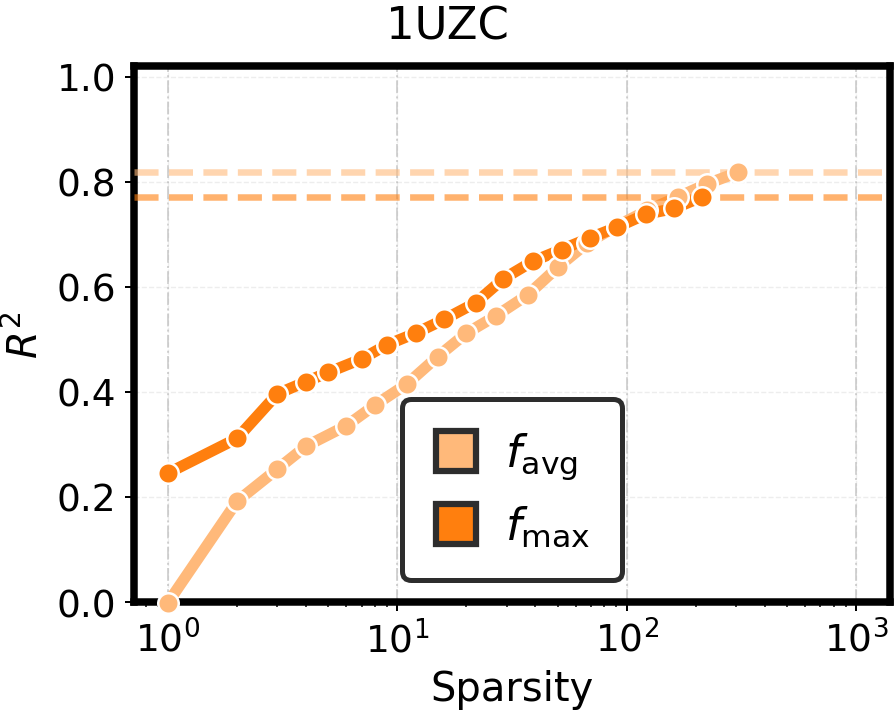

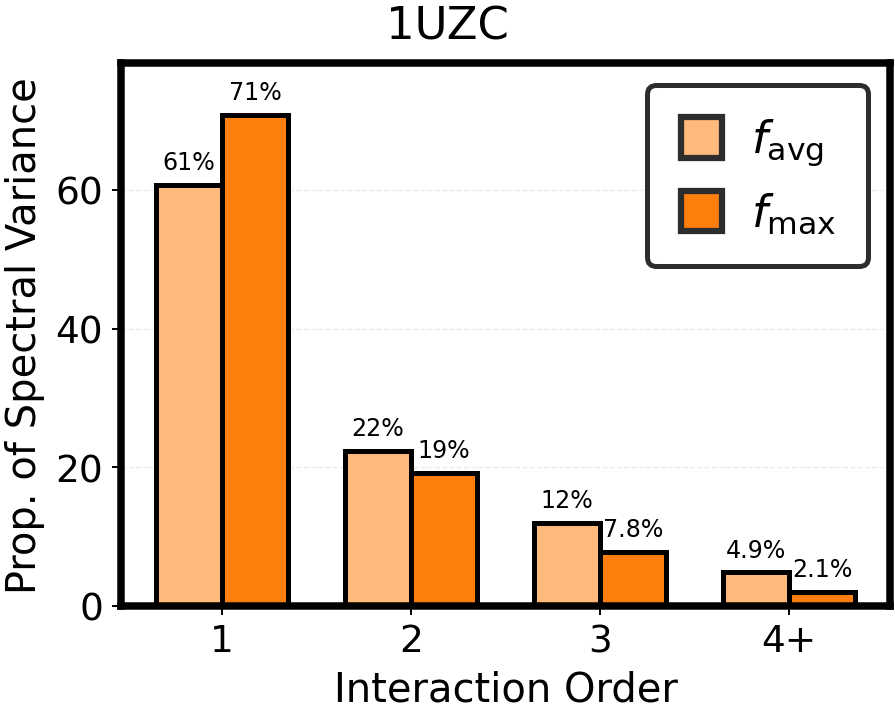

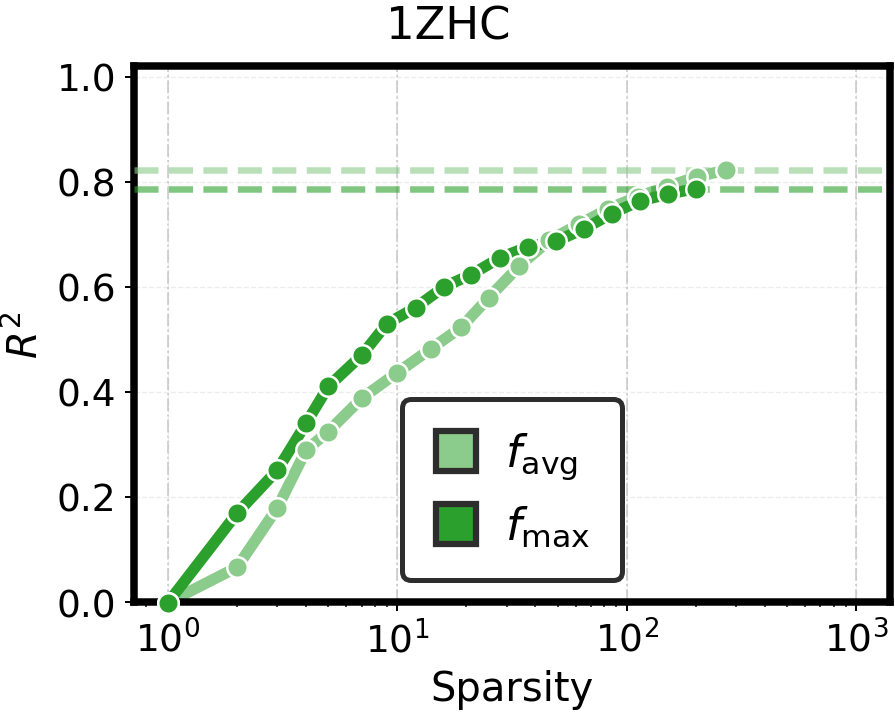

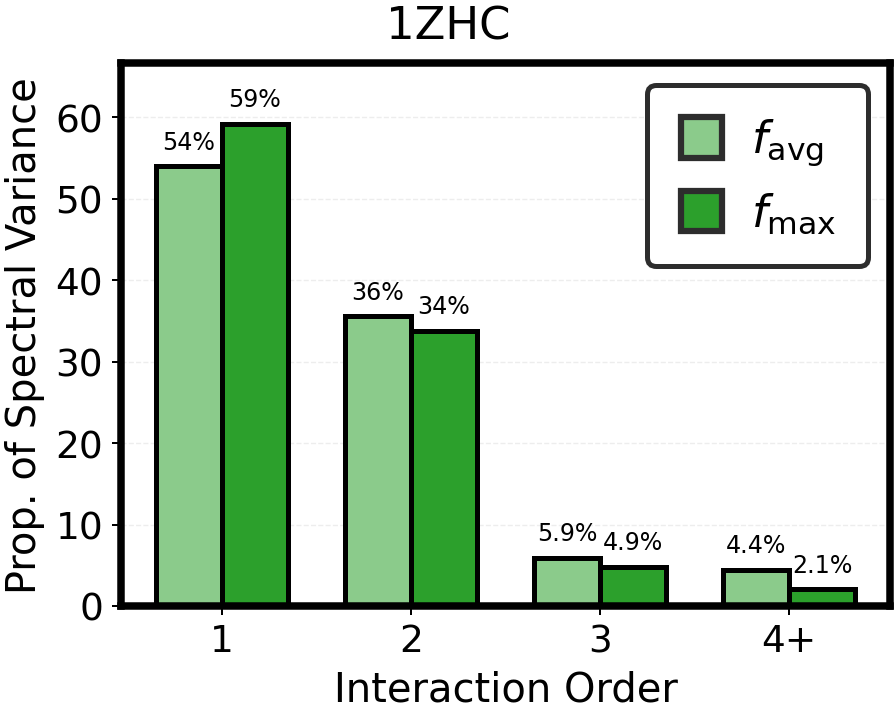

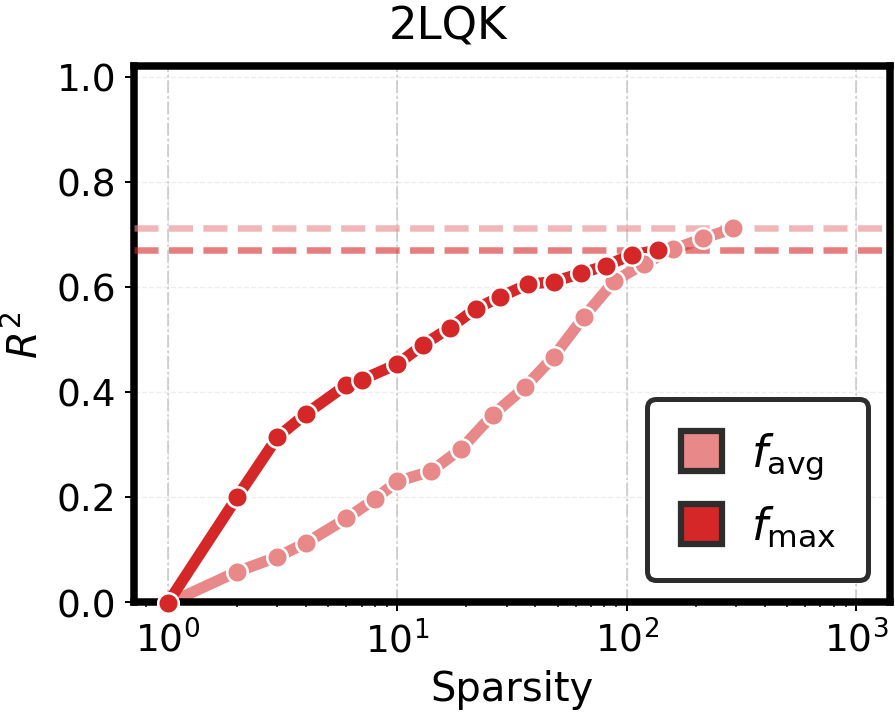

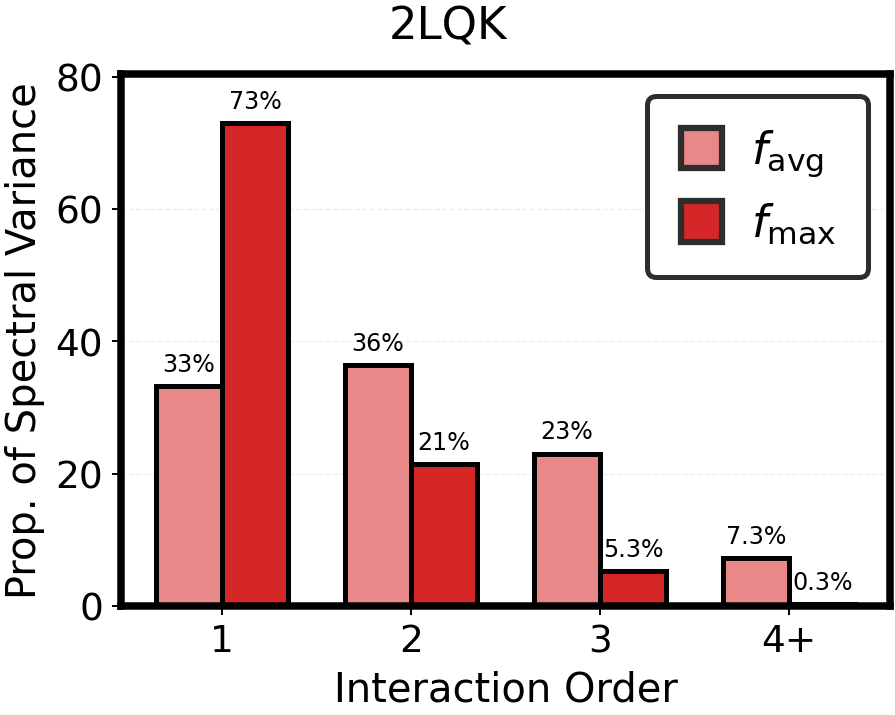

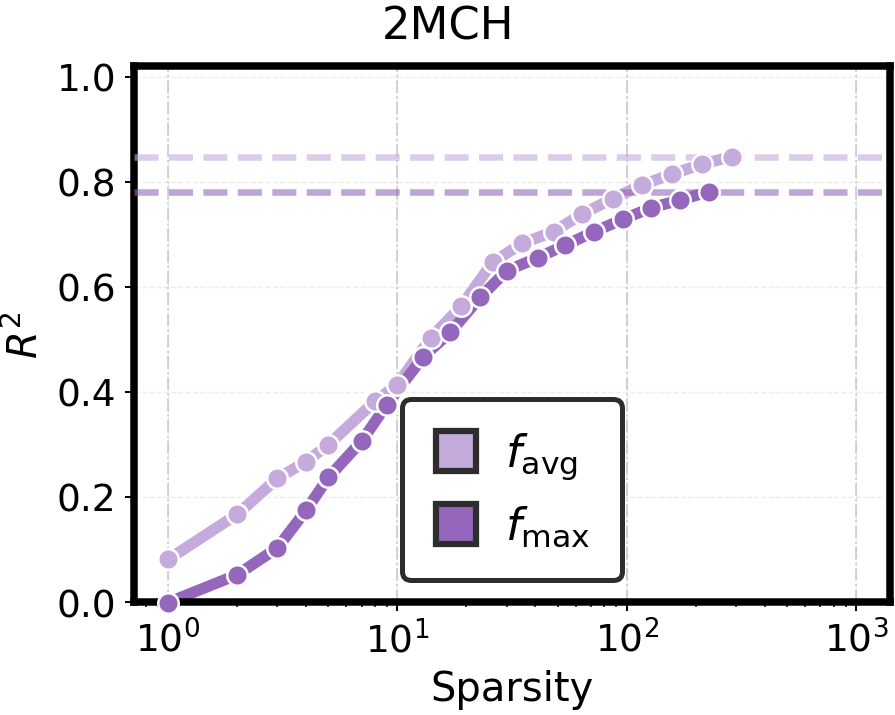

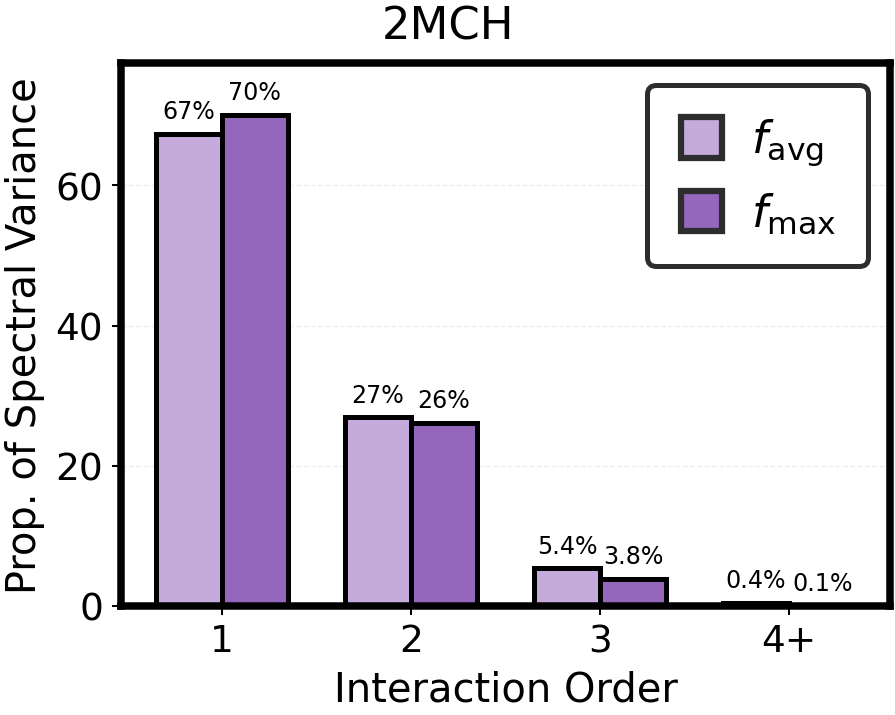

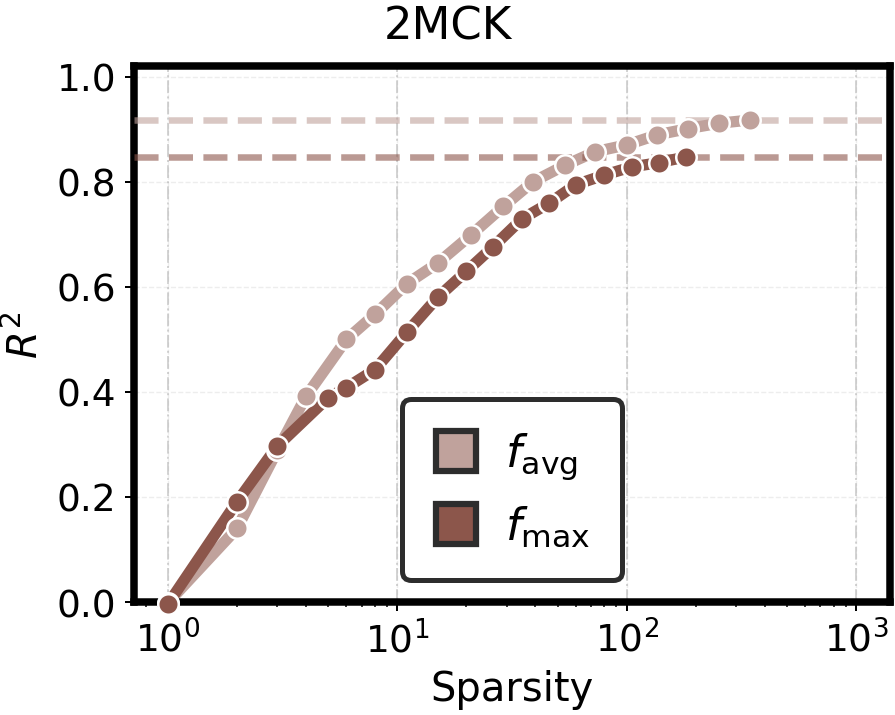

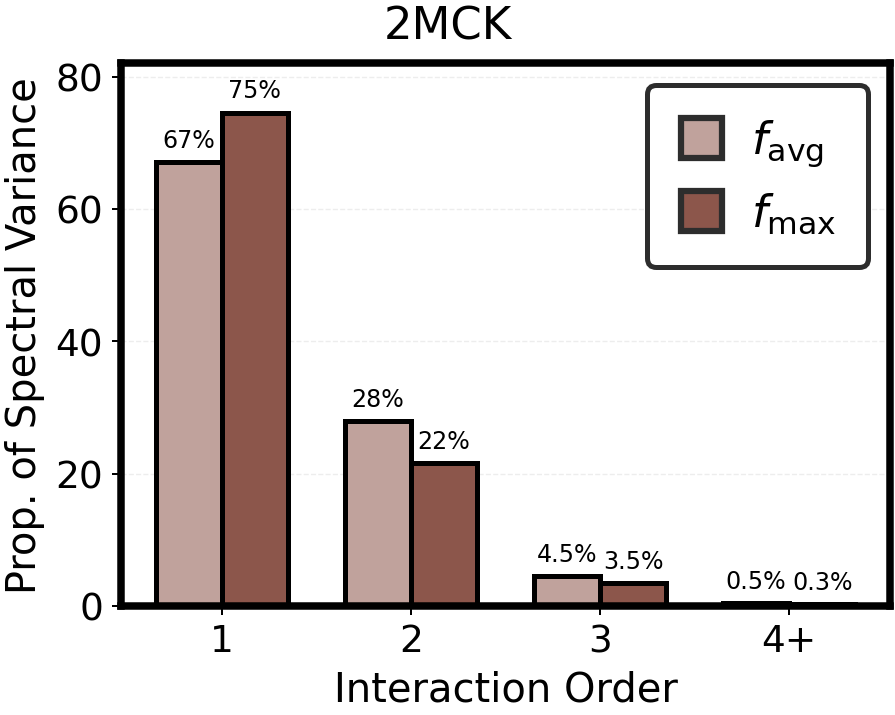

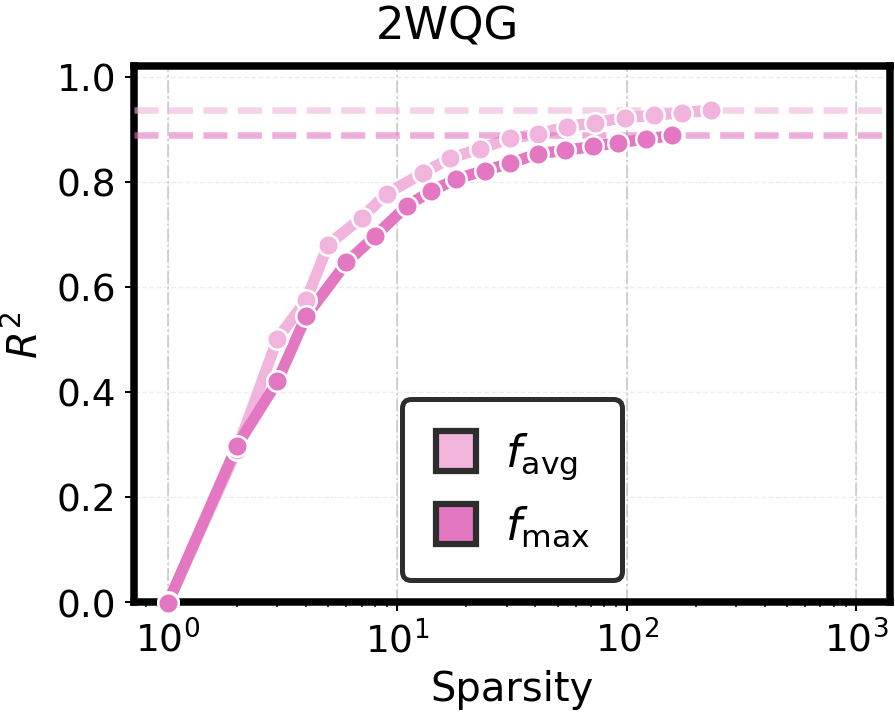

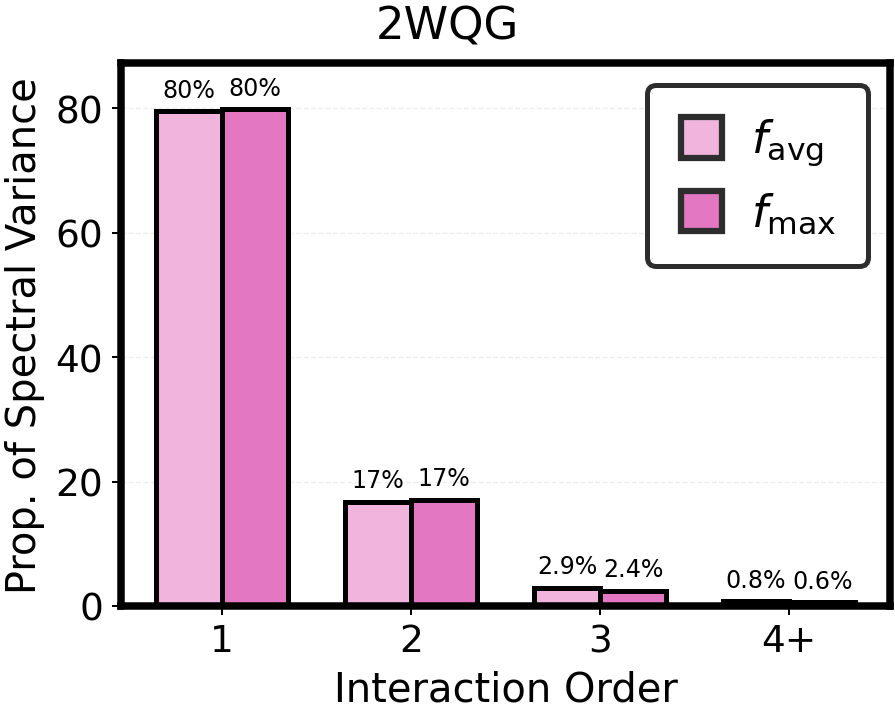

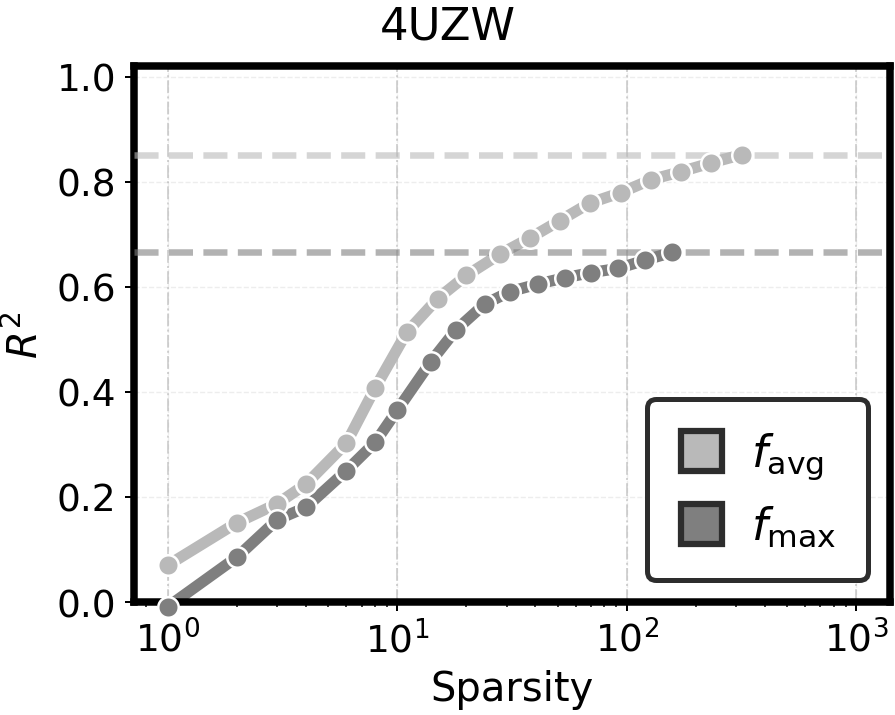

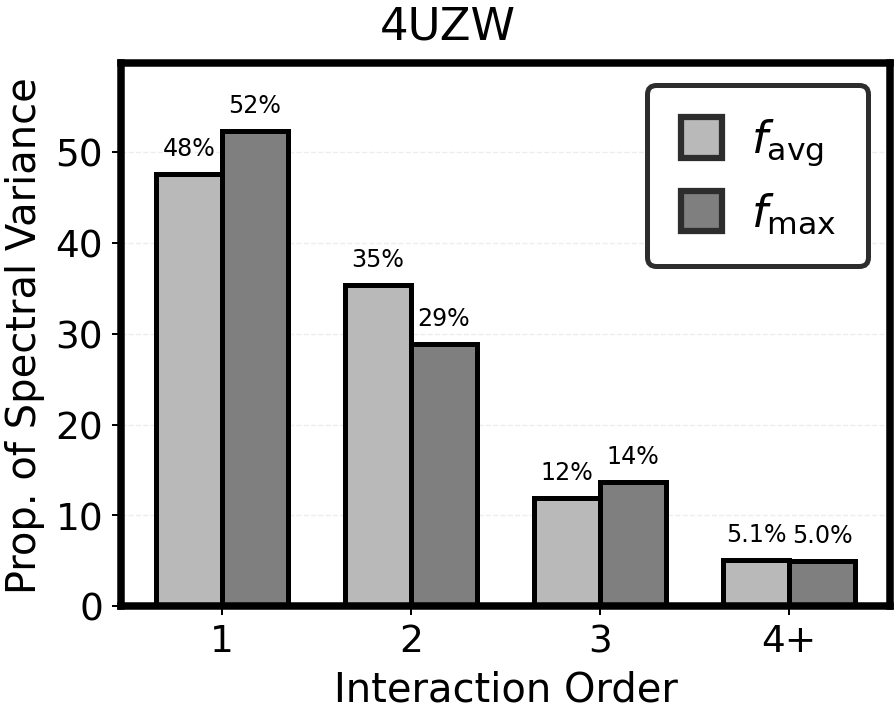

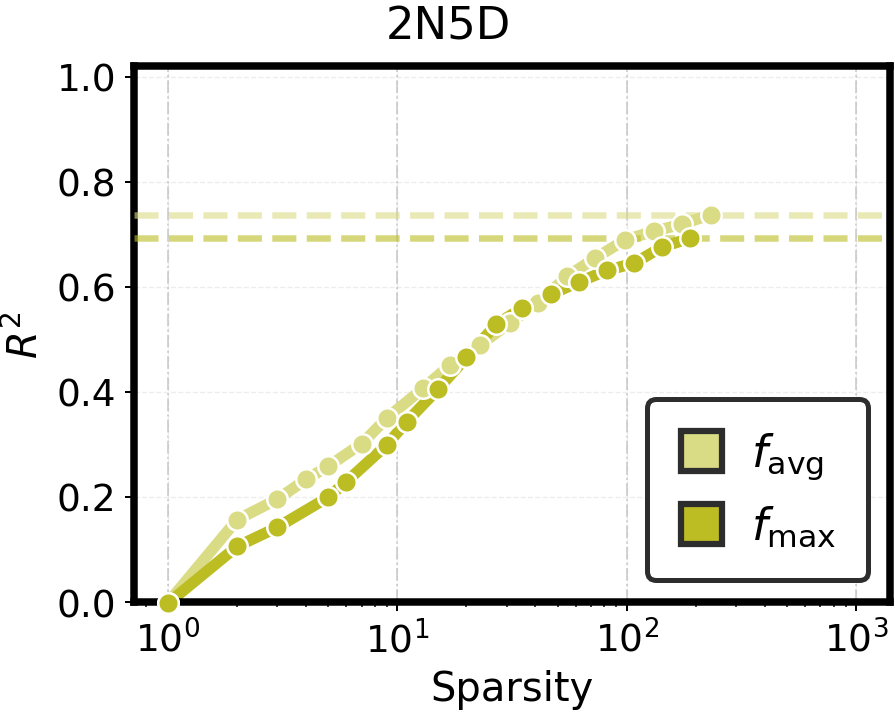

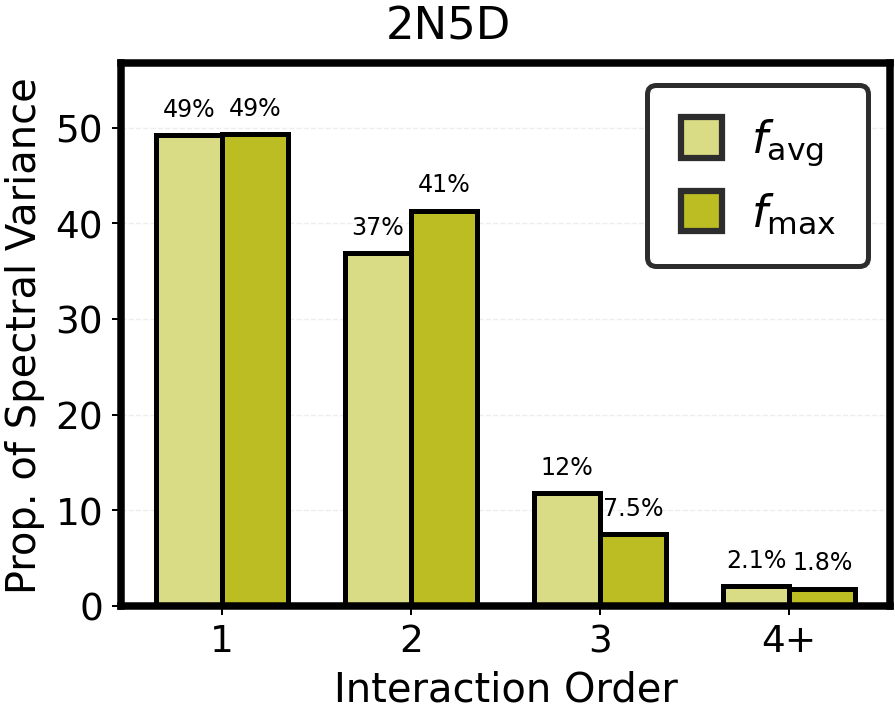

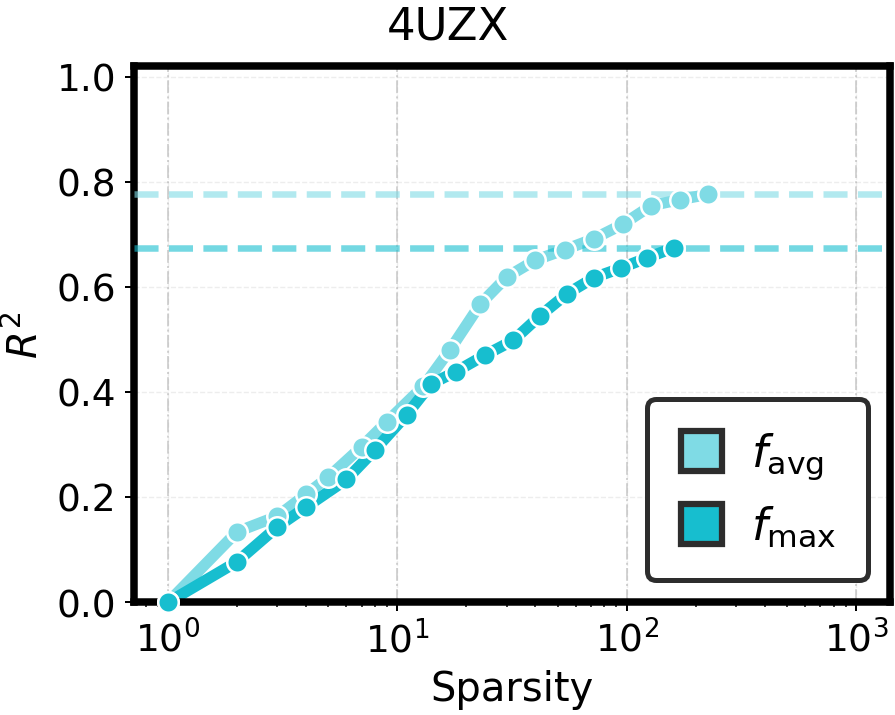

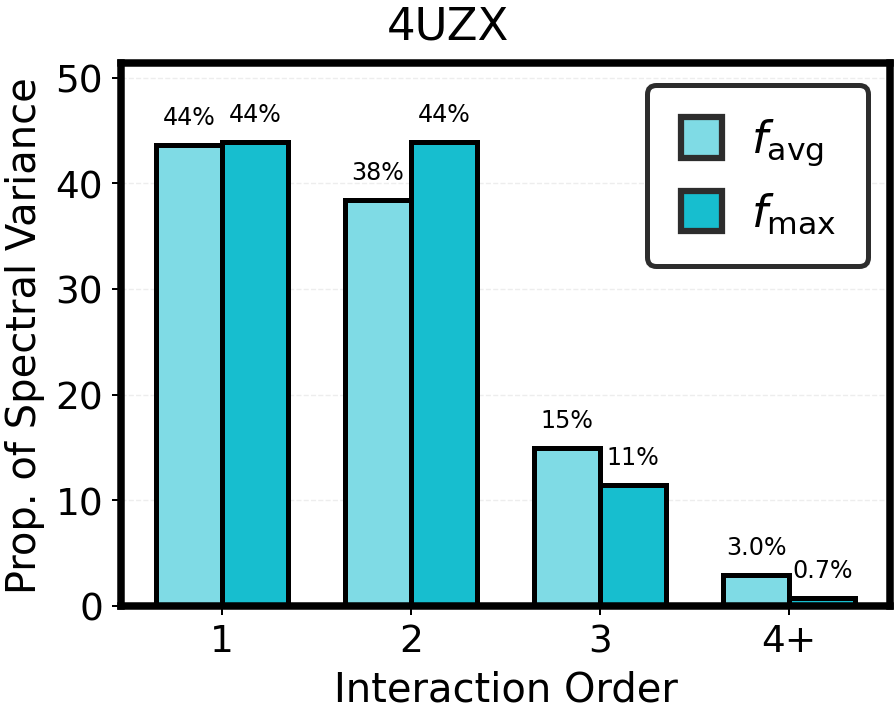

Wrote PDFs to /u/sdickman/DRAKES/drakes_protein/fmif/eval_results/spex_logs/figs


In [9]:
OUT = "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/spex_logs/figs"
os.makedirs(OUT, exist_ok=True)

LABELS = []
for p in PROTEINS:
    p_name = p[0].upper()
    if p_name == "V2_4UZX":
        p_name = "4UZX"
    elif p_name == "V2R31S|R32S_2N5D":
        p_name = "2N5D"
    LABELS.append(p_name)
COLORS = mpl.cm.tab10.colors

LINE_W    = 4.5
SPINE_LW  = 3
MARKER_S  = 8.2
MAX_ORDER = 4
BAR_W     = 0.35


def load_protein_data(name, time):
    data_dir = "/u/sdickman/DRAKES/drakes_protein/fmif/eval_results/spex_logs/r2_data/"
    cand = os.path.join(data_dir, f"fourier_dict__{name}_{time}.pkl")
    fourier_dict = pickle.load(open(cand, "rb"))
    rmax = TIME_STAMP_RMAX_MAP[time]
    heldout_masks = np.loadtxt(data_dir + f"heldout_masks__{name}_max={rmax}_{time}.txt", dtype=int).astype(bool)
    y_true = np.loadtxt(data_dir + f"y_true__{name}_max={rmax}_{time}.txt")

    def reconstruct(masks, fdict):
        masks = np.asarray(masks, dtype=bool)
        preds = np.zeros(len(masks), dtype=float)
        for freq, coef in fdict.items():
            active = np.asarray(freq, dtype=bool)
            if not active.any():
                preds += float(coef)
            else:
                preds += float(coef) * ((-1) ** (masks[:, active].sum(axis=1) % 2))
        return preds

    full_r2 = r2_score(y_true, reconstruct(heldout_masks, fourier_dict))

    sorted_items = sorted(fourier_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    steps = np.unique(np.geomspace(1, len(sorted_items), num=20, dtype=int))
    k_values, r2_values = [], []
    for k in steps:
        k_values.append(k)
        r2_values.append(r2_score(y_true, reconstruct(heldout_masks, dict(sorted_items[:k]))))

    energy_by_order = {}
    for key_tuple, coef in fourier_dict.items():
        order = min(int(sum(key_tuple)), MAX_ORDER)
        if order == 0:
            continue
        energy_by_order[order] = energy_by_order.get(order, 0.0) + float(coef) ** 2

    orders = sorted(energy_by_order)
    variances = np.array([energy_by_order[o] for o in orders], dtype=float)
    percentages = 100 * variances / variances.sum() if variances.sum() > 0 else np.zeros_like(variances)

    return k_values, r2_values, full_r2, orders, percentages


def lighten(color, amount=0.45):
    """Blend color toward white by amount (0 = no change, 1 = pure white)."""
    c = np.array(mpl.colors.to_rgb(color))
    return tuple(c + amount * (1.0 - c))


from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerPatch


class SquarePatchHandler(HandlerPatch):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        size = height
        x = xdescent + (width - size) / 2
        sq = Rectangle(
            (x, ydescent - 4.0), size, size,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth(),
            transform=trans,
        )
        return [sq]


np.random.seed(42)

# Group proteins by display label so each protein gets one pair of figures.
# protein_groups[label] = {'name': str, 'avg': data_tuple, 'max': data_tuple}
protein_groups = {}
color_index    = {}

for (name, time), label in zip(PROTEINS, LABELS):
    rmax = TIME_STAMP_RMAX_MAP[time]
    if label not in protein_groups:
        protein_groups[label] = {'name': name}
        color_index[label] = len(color_index)
    variant = 'max' if rmax else 'avg'
    protein_groups[label][variant] = load_protein_data(name, time)
# Collect the average last data point for 'max' and 'avg' trajectories across all proteins,
# and the average proportion of variance captured in the first two interaction orders.

max_last_points = []
avg_last_points = []
order1_props = []
order2_props = []

for label, grp in protein_groups.items():
    for v in ['avg', 'max']:
        if v in grp:
            k_values, r2_values, full_r2, orders, percentages = grp[v]
            # Last data point for this trajectory
            if len(r2_values) > 0:
                if v == 'max':
                    max_last_points.append(r2_values[-1])
                elif v == 'avg':
                    avg_last_points.append(r2_values[-1])
            # Capture proportions for first two interaction orders
            if len(percentages) > 0:
                order1_props.append(percentages[0])
            if len(percentages) > 1:
                order2_props.append(percentages[1])

# Compute averages
average_last_max = np.mean(max_last_points) if max_last_points else np.nan
average_last_avg = np.mean(avg_last_points) if avg_last_points else np.nan
average_prop_order1 = np.mean(order1_props) if order1_props else np.nan
average_prop_order2 = np.mean(order2_props) if order2_props else np.nan

print(f"Average last data point (max): {average_last_max:.4f}")
print(f"Average last data point (avg): {average_last_avg:.4f}")
print(f"Average % variance, order 1: {average_prop_order1:.2f}%")
print(f"Average % variance, order 2: {average_prop_order2:.2f}%")
print(f"Total % variance, orders 1-2: {average_prop_order1 + average_prop_order2:.2f}%")

# Variant order: avg first, max second
VARIANTS = [
    ('avg', r'$f_{\mathrm{avg}}$'),
    ('max', r'$f_{\mathrm{max}}$'),
]

with plt.rc_context(NEURIPS_RC):
    fig_w, fig_h = 5, 4#3.5

    for label, grp in protein_groups.items():
        ci         = color_index[label]
        base_color = COLORS[ci % len(COLORS)]
        # Two shades from the same tab10 hue: lighter for avg, base for max
        variant_colors = {
            'avg': lighten(base_color, 0.45),
            'max': base_color,
        }

        present = [v for v, _ in VARIANTS if v in grp]

        legend_handles = [
            Patch(facecolor=variant_colors[v], edgecolor="#2d2d2d", linewidth=2.5,
                  label=s)
            for v, s in VARIANTS if v in grp
        ]
        LEGEND_KW = dict(
            handles=legend_handles,
            handler_map={Patch: SquarePatchHandler()},
            frameon=True,
            fancybox=True,
            framealpha=1.0,
            edgecolor="#2d2d2d",
            borderpad=0.7,
            handlelength=1.0,
            handleheight=1.0,
            handletextpad=0.6,
            fontsize=18,
        )

        # ── Sparsity figure ──────────────────────────────────────────────────
        fig_sp, ax_sp = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

        for v, _ in VARIANTS:
            if v not in grp:
                continue
            k_values, r2_values, full_r2, _, _ = grp[v]
            color = variant_colors[v]
            ax_sp.plot(k_values, r2_values, linestyle="-", linewidth=LINE_W,
                       color=color, marker=None, zorder=2)
            ax_sp.axhline(full_r2, color=color, linestyle="--", linewidth=2.6,
                          alpha=0.6, zorder=3)
            ax_sp.scatter(k_values, r2_values, s=MARKER_S ** 2,
                          facecolors=color, edgecolors="white", linewidths=1.0,
                          zorder=5, clip_on=False)

        ax_sp.set_xscale("log")
        ax_sp.set_ylim(0, 1.02)
        ax_sp.set_xlabel("Sparsity")
        ax_sp.set_ylabel(r"$R^2$")
        ax_sp.grid(True, which="major")
        ax_sp.grid(False, which="minor")
        ax_sp.set_axisbelow(True)
        for x_dec in (1, 10, 100, 1000):
            ax_sp.axvline(x_dec, color="#B2B2B2", linewidth=0.8, linestyle="-.", alpha=0.55, zorder=1)
        for _sp in ax_sp.spines.values():
            _sp.set_visible(True)
            _sp.set_linewidth(SPINE_LW)
        leg = ax_sp.legend(**LEGEND_KW)
        leg.get_frame().set_linewidth(2.0)

        fig_sp.suptitle(label, fontsize=18, fontweight="normal")
        fig_sp.savefig(os.path.join(OUT, f"{grp['name']}_sparsity.pdf"), format="pdf")
        plt.show()
        plt.close(fig_sp)

        # ── Variance figure ──────────────────────────────────────────────────
        fig_var, ax_var = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

        all_orders = sorted({o for v, _ in VARIANTS if v in grp for o in grp[v][3]})
        x = np.arange(len(all_orders))
        dy = 1.5

        max_val = 0.0
        for v, _ in VARIANTS:
            if v in grp and len(grp[v][4]):
                max_val = max(max_val, float(grp[v][4].max()))

        for i, v in enumerate(present):
            _, _, _, orders, percentages = grp[v]
            color = variant_colors[v]
            pct_map = dict(zip(orders, percentages))
            vals = [pct_map.get(o, 0.0) for o in all_orders]
            offset = (i - (len(present) - 1) / 2) * BAR_W
            bars_collection = ax_var.bar(x + offset, vals, BAR_W,
                                         color=color, edgecolor="black",
                                         linewidth=2, alpha=1)
            for bar, val in zip(bars_collection, vals):
                if val > 0:
                    pct_s = f"{val:.0f}%" if val >= 10 else f"{val:.1f}%"
                    ax_var.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + dy,
                        pct_s,
                        ha="center", va="bottom",
                        fontsize=9.5, color="#000000",
                    )

        ax_var.set_ylim(0, max_val + dy + 6)
        ax_var.set_xlabel("Interaction Order")
        ax_var.set_ylabel("Prop. of Spectral Variance")
        ax_var.set_xticks(x)
        ax_var.set_xticklabels([str(o) if o < MAX_ORDER else f"{MAX_ORDER}+" for o in all_orders])
        ax_var.grid(True, axis="y")
        ax_var.grid(False, axis="x")
        ax_var.set_axisbelow(True)
        for _sp in ax_var.spines.values():
            _sp.set_visible(True)
            _sp.set_linewidth(SPINE_LW)
        leg = ax_var.legend(**LEGEND_KW)
        leg.get_frame().set_linewidth(2.0)

        fig_var.suptitle(label, fontsize=18, fontweight="normal")
        fig_var.savefig(os.path.join(OUT, f"{grp['name']}_variance.pdf"), format="pdf")
        plt.show()
        plt.close(fig_var)

print("Wrote PDFs to", OUT)


In [105]:
# display_time('2L09', '20260428-100017', rmax=False)

Held out masks shape: (1024, 66)
Successfully loaded experiment: 20260428-013719
R2 Score on 1000 held-out masks: 0.7886


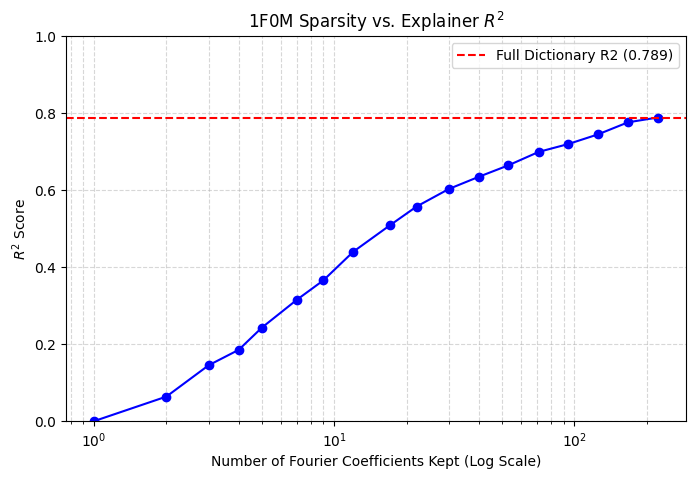

Mean term c_empty: 0.783386
Mean contribution c_empty^2: 0.613694
Total variance from spectrum: 0.000531

--- Variance by Interaction Order ---
Order 1: 0.000393 (74.02%)
Order 2: 0.000111 (20.91%)
Order 3: 0.000025 (4.71%)
Order 4: 0.000002 (0.36%)


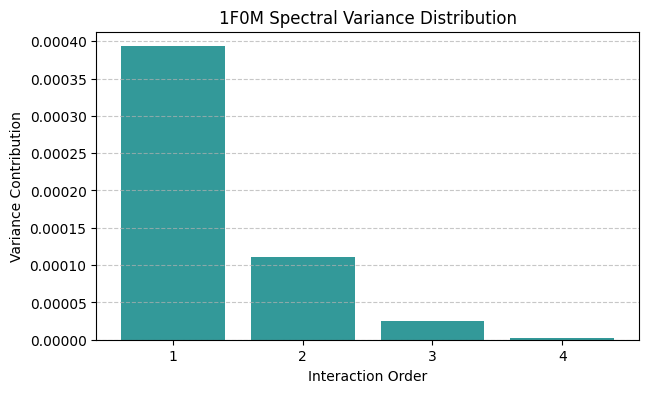

Held out masks shape: (1024, 52)
Successfully loaded experiment: 20260428-043722
R2 Score on 1000 held-out masks: 0.8459


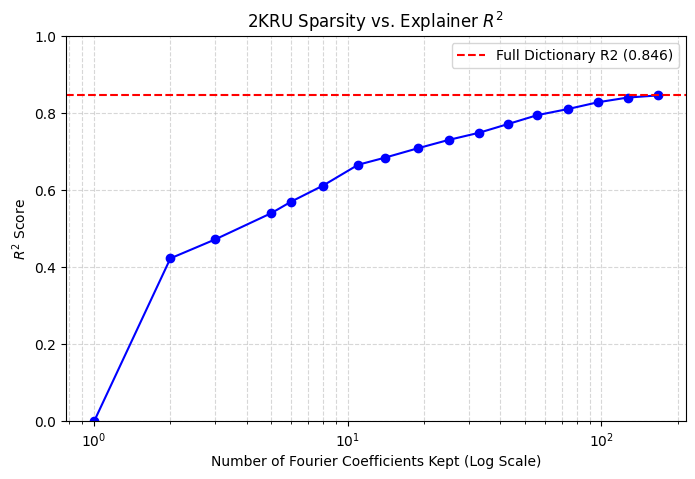

Mean term c_empty: 0.547048
Mean contribution c_empty^2: 0.299262
Total variance from spectrum: 0.004493

--- Variance by Interaction Order ---
Order 1: 0.003452 (76.82%)
Order 2: 0.000881 (19.60%)
Order 3: 0.000142 (3.17%)
Order 4: 0.000013 (0.28%)
Order 5: 0.000006 (0.13%)


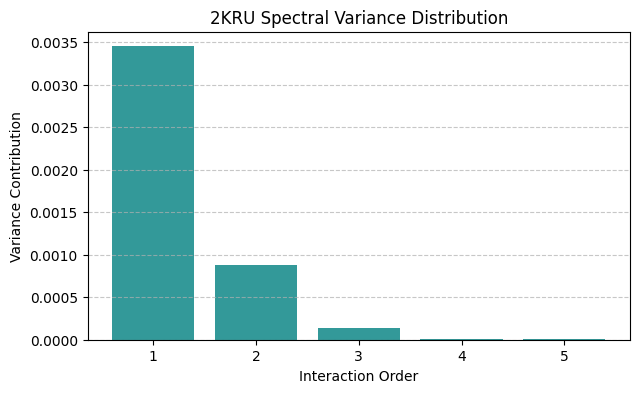

Held out masks shape: (1024, 52)
Successfully loaded experiment: 20260428-012947
R2 Score on 1000 held-out masks: 0.6611


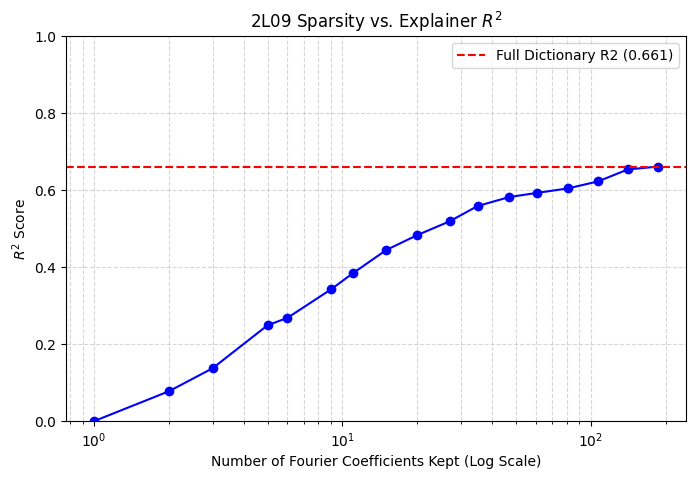

Mean term c_empty: 0.267521
Mean contribution c_empty^2: 0.071567
Total variance from spectrum: 0.004081

--- Variance by Interaction Order ---
Order 1: 0.002124 (52.05%)
Order 2: 0.001355 (33.19%)
Order 3: 0.000524 (12.83%)
Order 4: 0.000079 (1.93%)


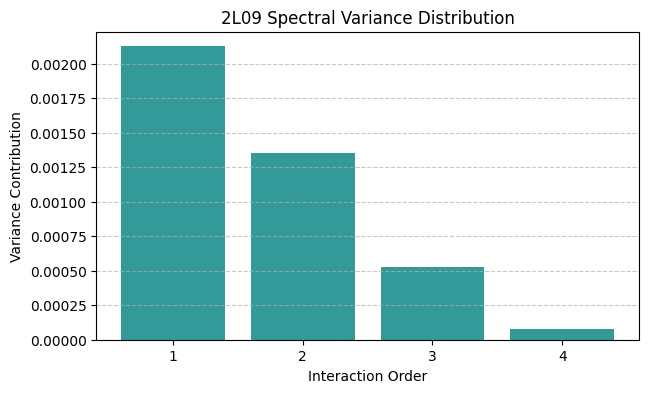

Held out masks shape: (1024, 46)
Successfully loaded experiment: 20260428-030742
R2 Score on 1000 held-out masks: 0.8456


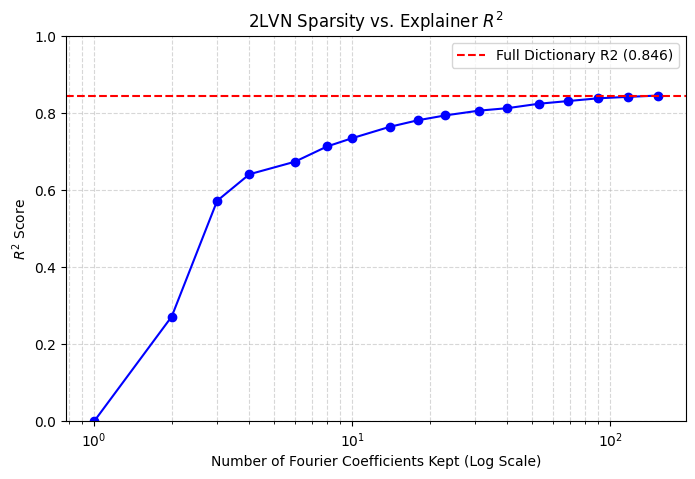

Mean term c_empty: 0.222463
Mean contribution c_empty^2: 0.049490
Total variance from spectrum: 0.027797

--- Variance by Interaction Order ---
Order 1: 0.014723 (52.97%)
Order 2: 0.012072 (43.43%)
Order 3: 0.000859 (3.09%)
Order 4: 0.000144 (0.52%)


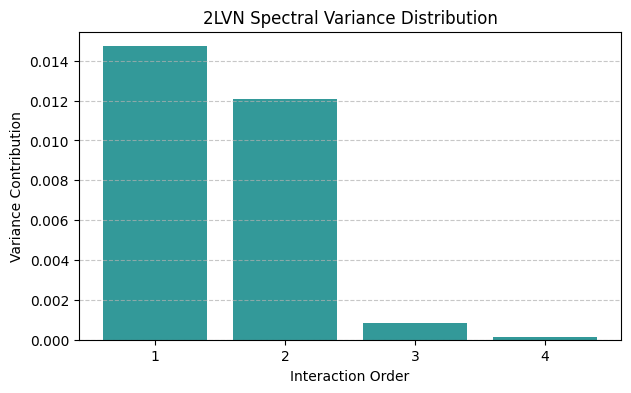

Held out masks shape: (1024, 71)
Successfully loaded experiment: 20260428-023032
R2 Score on 1000 held-out masks: 0.5994


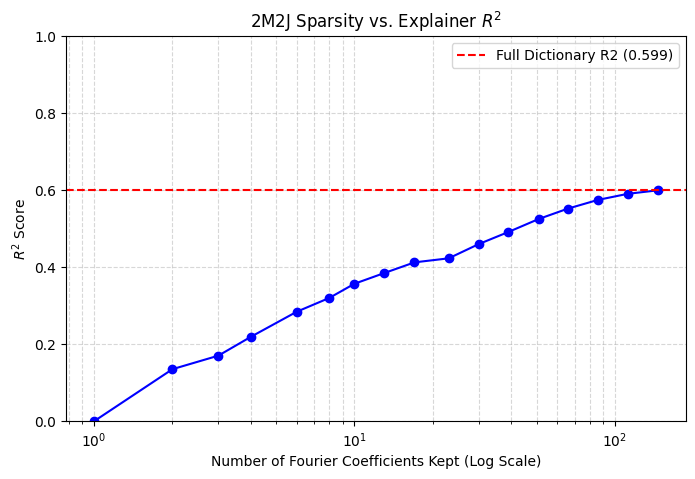

Mean term c_empty: 0.460025
Mean contribution c_empty^2: 0.211623
Total variance from spectrum: 0.010517

--- Variance by Interaction Order ---
Order 1: 0.005853 (55.65%)
Order 2: 0.003828 (36.40%)
Order 3: 0.000821 (7.81%)
Order 4: 0.000015 (0.14%)


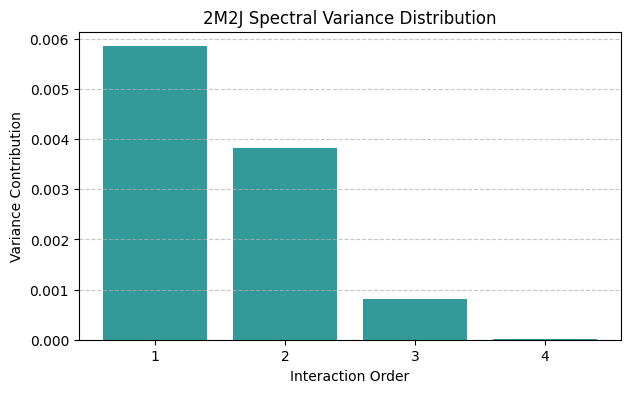

Held out masks shape: (1024, 70)
Successfully loaded experiment: 20260428-034602
R2 Score on 1000 held-out masks: 0.6352


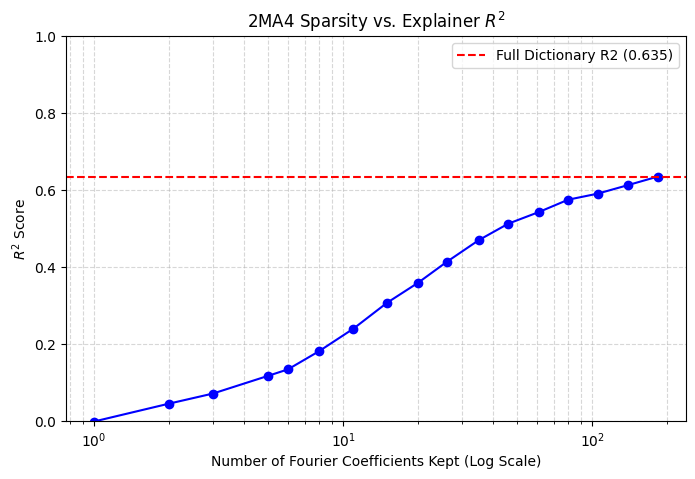

Mean term c_empty: 0.239924
Mean contribution c_empty^2: 0.057564
Total variance from spectrum: 0.014278

--- Variance by Interaction Order ---
Order 1: 0.005495 (38.49%)
Order 2: 0.006467 (45.30%)
Order 3: 0.001879 (13.16%)
Order 4: 0.000235 (1.64%)
Order 5: 0.000201 (1.41%)


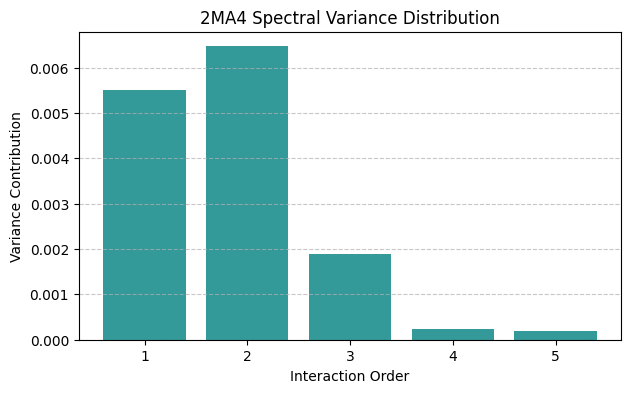

Held out masks shape: (1024, 47)
Successfully loaded experiment: 20260428-021920
R2 Score on 1000 held-out masks: 0.8053


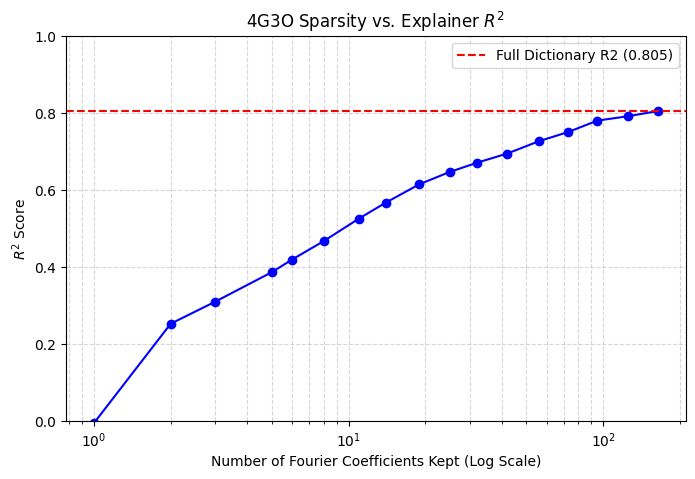

Mean term c_empty: 0.593369
Mean contribution c_empty^2: 0.352086
Total variance from spectrum: 0.013361

--- Variance by Interaction Order ---
Order 1: 0.004321 (32.34%)
Order 2: 0.007191 (53.82%)
Order 3: 0.001489 (11.14%)
Order 4: 0.000330 (2.47%)
Order 5: 0.000031 (0.24%)


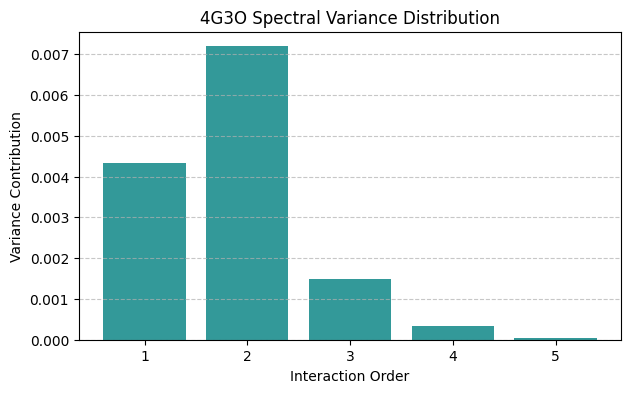

Held out masks shape: (1024, 59)
Successfully loaded experiment: 20260428-024054
R2 Score on 1000 held-out masks: 0.8413


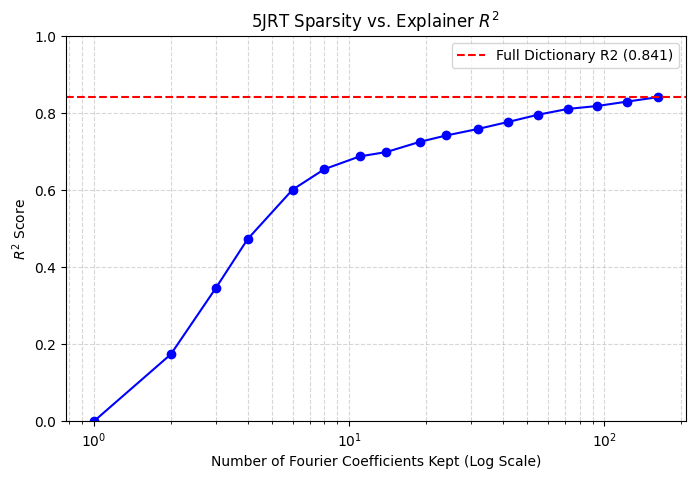

Mean term c_empty: 0.502863
Mean contribution c_empty^2: 0.252872
Total variance from spectrum: 0.002846

--- Variance by Interaction Order ---
Order 1: 0.002014 (70.76%)
Order 2: 0.000725 (25.47%)
Order 3: 0.000101 (3.54%)
Order 4: 0.000006 (0.22%)


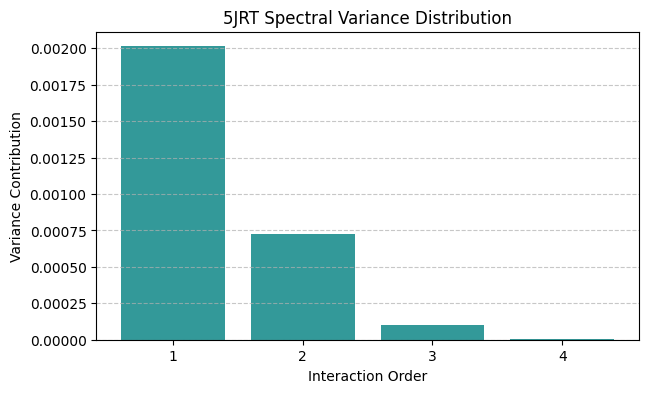

Held out masks shape: (1024, 57)
Successfully loaded experiment: 20260428-034159
R2 Score on 1000 held-out masks: 0.7302


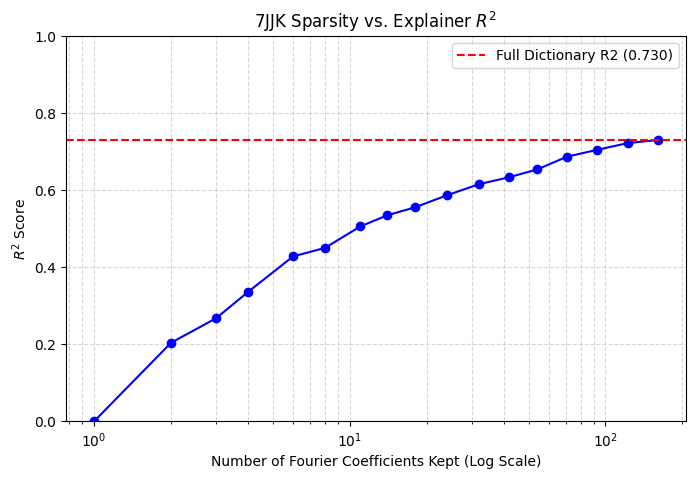

Mean term c_empty: 0.658276
Mean contribution c_empty^2: 0.433327
Total variance from spectrum: 0.001029

--- Variance by Interaction Order ---
Order 1: 0.000653 (63.47%)
Order 2: 0.000294 (28.53%)
Order 3: 0.000058 (5.63%)
Order 4: 0.000023 (2.26%)
Order 5: 0.000001 (0.10%)


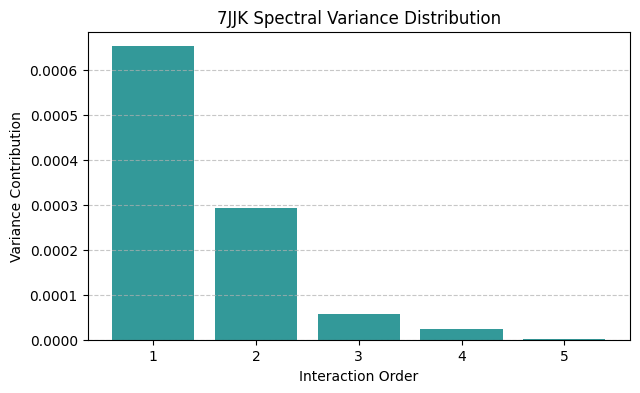

Held out masks shape: (1024, 43)
Successfully loaded experiment: 20260428-011444
R2 Score on 1000 held-out masks: 0.8225


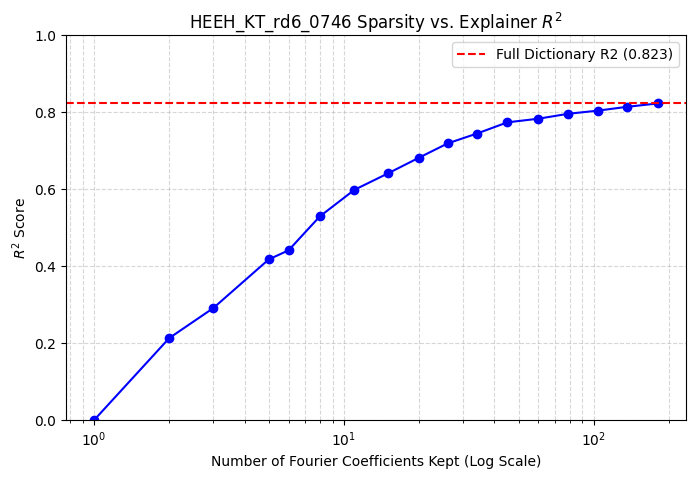

Mean term c_empty: 0.281780
Mean contribution c_empty^2: 0.079400
Total variance from spectrum: 0.017988

--- Variance by Interaction Order ---
Order 1: 0.014153 (78.68%)
Order 2: 0.003128 (17.39%)
Order 3: 0.000583 (3.24%)
Order 4: 0.000105 (0.58%)
Order 5: 0.000019 (0.10%)


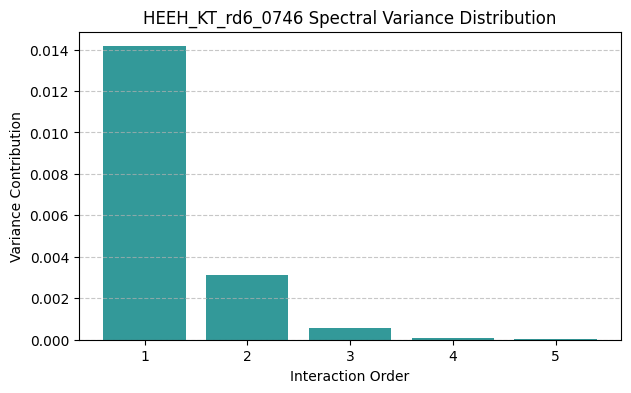

Held out masks shape: (1024, 56)
Successfully loaded experiment: 20260428-002915
R2 Score on 1000 held-out masks: 0.7129


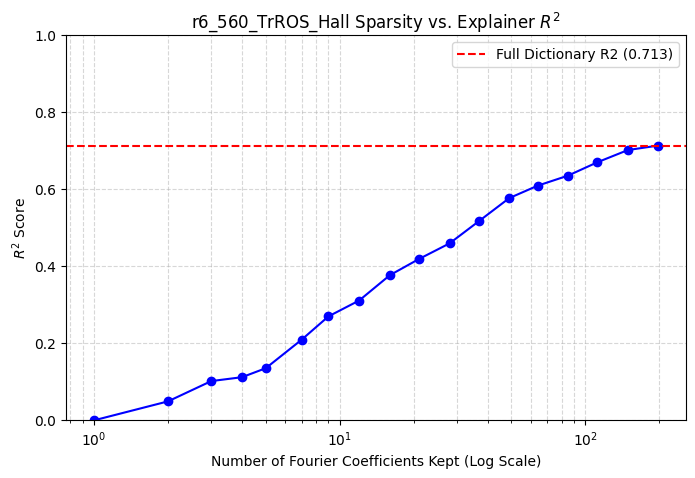

Mean term c_empty: 0.567465
Mean contribution c_empty^2: 0.322017
Total variance from spectrum: 0.001676

--- Variance by Interaction Order ---
Order 1: 0.000701 (41.81%)
Order 2: 0.000614 (36.62%)
Order 3: 0.000302 (18.03%)
Order 4: 0.000054 (3.21%)
Order 5: 0.000005 (0.32%)


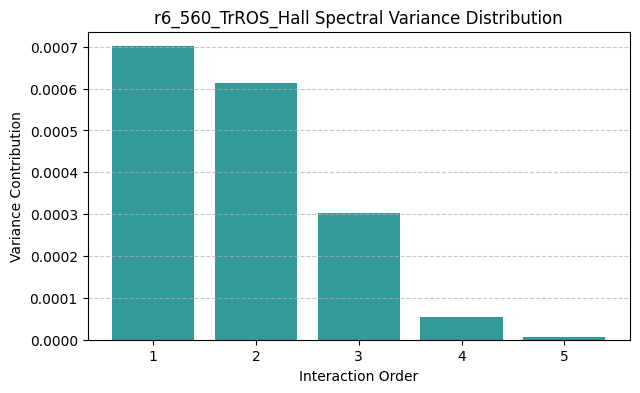

In [ ]:
names = ['1F0M', '2KRU', '2L09', '2LVN', '2M2J', '2MA4', '4G3O', '5JRT', '7JJK', 'HEEH_KT_rd6_0746', 'r6_560_TrROS_Hall']
times = ['20260428-013719', '20260428-043722', '20260428-012947', '20260428-030742', '20260428-023032', '20260428-034602', '20260428-021920', '20260428-024054', '20260428-034159', '20260428-011444', '20260428-002915']

for n, t in zip(names, times):
    display_time(n, t)

In [ ]:
OUT = "/projects/beir/lbutler3/protein"
os.makedirs(OUT, exist_ok=True)
display_time(
    "r6_560_TrROS_Hall",
    "20260428-002915",
    save_path=os.path.join(OUT, "r6_560_trros_hall_spex_merged.pdf"),
)
display_time(
    "2KRU",
    "20260428-043722",
    save_path=os.path.join(OUT, "2kru_spex_merged.pdf"),
)
print("Wrote:", OUT)
